## Baseline Pre vs. Post  

Leadership starts with:  "What happened before vs. after the promo?"  

*We need to establish a baseline to compare to other models*

The clean progression should be:  

		1. Naïve pre/post (treated only)  
		2. Naïve treated vs control (post only)  
		3. Explain why both are flawed  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 


In [4]:
# Read in synthetic data

df = pd.read_csv("data/raw/project_google_synth.csv")
df.head(2)

,user_id,date,dow,post,exposed,treated_group,discount_pct,region,device_type,traffic_source,...,list_price,gross_sales_pre_discount,net_revenue,unit_cost,total_cost,margin_dollars,margin_rate,counterfactual_units,counterfactual_revenue,counterfactual_margin_dollars
0,0,2025-11-01,5,0,0,0,0.0,South,Desktop,Email,...,16.856929,16.856929,16.856929,11.017525,11.017525,5.839403,0.34641,1,16.856929,5.839403
1,0,2025-11-02,6,0,0,0,0.0,South,Desktop,Email,...,16.856929,33.713857,33.713857,11.017525,22.035051,11.678807,0.34641,2,33.713857,11.678807


### 1. Treated Users: Pre vs. Post  

Question: Among exposed users, what changed after the promo started?  

It will be biased because:   

    - it ignores seasonality  
    - it ignores structural differences (selection bias)  
    - it assumes no other time effects  

In [12]:
pre = df[df['post']==0].copy()
promo = df[df['post'] == 1].copy()

# treated_users = promo[promo["exposed"]==1]["user_id"].unique()

# pre_promo = df[
#     (df['post']==0) & 
#     (df['user_id'].isin(treated_users))
#     ]["margin_dollars"].mean()

# post_promo = df[
#     (df['post']==1) & 
#     (df['user_id'].isin(treated_users))
#     ]["margin_dollars"].mean()

treated = df[df['ever_exposed']==1] #select only treated customers

pre_promo = treated[treated['post']==0]['margin_dollars'].mean()
post_promo = treated[treated['post']==1]['margin_dollars'].mean()

print("Treated Avg Margin (Pre): ", pre_promo)
print("Treated Avg Margin (Post): ", post_promo)
print("Treated Pre vs. Post Margin: ", post_promo - pre_promo)


Treated Avg Margin (Pre):  4.38082663455894
Treated Avg Margin (Post):  0.8409893205544657
Treated Pre vs. Post Margin:  -3.5398373140044748


### 2. Control Users: Pre vs. Post  

This shows:   

    - What happened over time without the promo  
    - This isolates time effect


In [13]:
control = df[df['ever_exposed']==0]

pre_promo_control = control[control['post']==0]['margin_dollars'].mean()
post_promo_control = control[control['post']==1]['margin_dollars'].mean()

print("Control Avg Margin (Pre): ", pre_promo_control)
print("Control Avg Margin (Post): ", post_promo_control)
print("Control Pre vs. Post Margin: ", post_promo_control - pre_promo_control)

Control Avg Margin (Pre):  3.3148231627216234
Control Avg Margin (Post):  4.370749405808979
Control Pre vs. Post Margin:  1.055926243087356


### 3. Compare the Two Changes  
  
- DiD removes the +1.06 time effect

In [15]:
treatment_delta = post_promo - pre_promo
control_delta = post_promo_control - pre_promo_control

print("Difference-in-Difference Est: ", treatment_delta - control_delta)

Difference-in-Difference Est:  -4.59576355709183


## Naive Post Difference  

A business leader may compute:  

    the average margin of treated user-days during the promo  
    minus  
    the average margin of control user-days during the promo  


Interpretation:

During promo, exposed users generated $5.61 less margin per day than unexposed users.

Why is this naïve?

Because it assumes:
$$
E[Y(0) \mid T=1] = E[Y(0) \mid T=0]
$$
Which we already proved is false. (see cell below naive lift)

So it mixes:
	•	True promo effect
	•	Selection bias

In [25]:
promo = df[df["post"] == 1]

naive_lift = (
    promo[promo["exposed"] == 1]["margin_dollars"].mean()
    - promo[promo["exposed"] == 0]["margin_dollars"].mean()
)

print("Naive Est: ", naive_lift)

Naive Est:  -5.605284638935568


In [24]:
promo = df[df["post"] == 1].copy()
print("if different, then selection bias.\nthe treatment customers are not the same as control customers")
print("-"*100)
print(promo.groupby("exposed")[[
    "prior_30d_spend",
    "engagement_score",
    "tenure_days"
]].mean())
print("-"*100)
print("the treated customers historically spend more, have better engagements, and slightly more tenure days")


if different, then selection bias.
the treatment customers are not the same as control customers
----------------------------------------------------------------------------------------------------
         prior_30d_spend  engagement_score  tenure_days
exposed                                                
0              57.952926         -0.194221   220.431430
1              79.982772          0.061620   227.257946
----------------------------------------------------------------------------------------------------
the treated customers historically spend more, have better engagements, and slightly more tenure days


## Naive Estimate Composition  

Note: in the real world you would NOT have true_att, which requires conterfactuals which don't exist

In [30]:
true_att = -6.5379548441275155 # not calculated in real life
selection_bias = 0.9326702051919469 # caculated
naive_post = -5.605284638935568 # naive estimate looks "less bad."

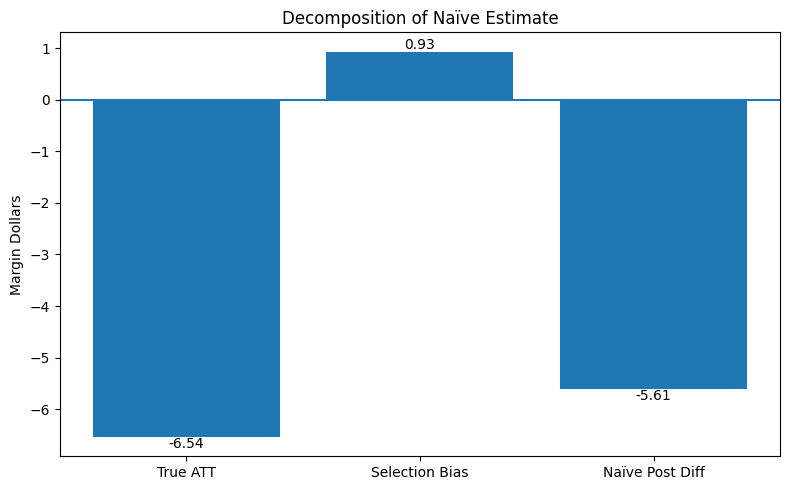

In [28]:

labels = ["True ATT", "Selection Bias", "Naïve Post Diff"]
values = [true_att, selection_bias, naive_post]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)

plt.axhline(0)

plt.title("Decomposition of Naïve Estimate")
plt.ylabel("Margin Dollars")

# Annotate values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.2f}",
             ha='center',
             va='bottom' if height > 0 else 'top')

plt.tight_layout()
plt.show()

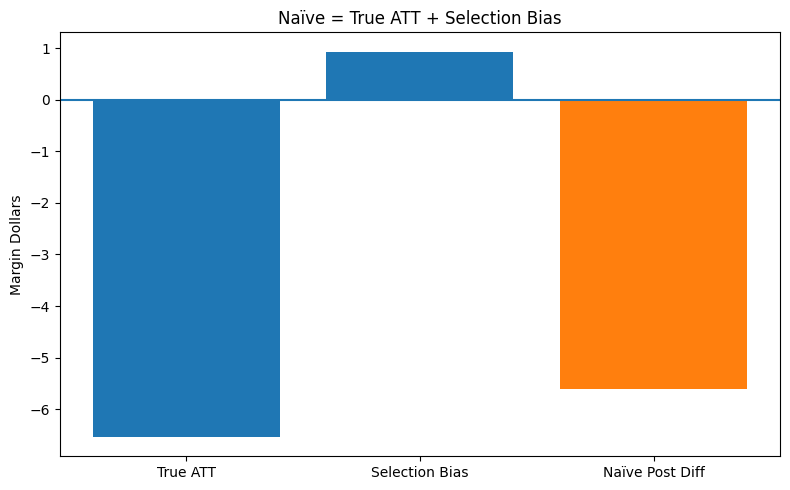

In [29]:

plt.figure(figsize=(8,5))

plt.bar(["True ATT", "Selection Bias"], [true_att, selection_bias])
plt.bar(["Naïve Post Diff"], [true_att + selection_bias])

plt.axhline(0)
plt.title("Naïve = True ATT + Selection Bias")
plt.ylabel("Margin Dollars")

plt.tight_layout()
plt.show()

In real life:  

	• You never observe counterfactual margin.
	• You can never compute true ATT directly.
	• You only approximate it using DiD, matching, regression.

Your synthetic setup lets you test how well those methods recover -6.538.